# Evaluation Metriken für Klassifikation

Accuracy ist nicht immer genug — manchmal ist sie sogar irreführend!  
In diesem Notebook lernst du alle Werkzeuge um ein Modell wirklich zu verstehen.

## Inhaltsverzeichnis
1. Warum Accuracy alleine nicht reicht
2. Die Confusion Matrix
3. Precision & Recall
4. F1-Score & Fbeta-Score
5. Wahrscheinlichkeits-Schwellwert (Threshold) anpassen
6. ROC-Kurve & AUC
7. Balanced Accuracy


## 1. Warum Accuracy alleine nicht reicht

**Beispiel:** Kreditkartenbetrug-Datensatz
- 99.8% der Transaktionen sind **normal**
- 0.2% sind **Betrug**

Ein Modell das **immer "normal"** vorhersagt:
```
Accuracy = 99.8% ← klingt super!
Aber: kein einziger Betrugsfall wird erkannt!
```

→ Accuracy ist bei **ungleichen Klassen** (Class Imbalance) eine schlechte Metrik.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score,
                              roc_curve, roc_auc_score, balanced_accuracy_score)

# Iris-Datensatz laden
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.DataFrame(iris.target, columns=['target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=41)

# Zwei Modelle trainieren
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

logit = LogisticRegression(C=0.95, max_iter=1000)
logit.fit(X_train, y_train)

print("KNN:                  Training: {:.2%} | Test: {:.2%}".format(
    knn.score(X_train, y_train), knn.score(X_test, y_test)))
print("Logistische Regression: Training: {:.2%} | Test: {:.2%}".format(
    logit.score(X_train, y_train), logit.score(X_test, y_test)))

KNN:                  Training: 100.00% | Test: 94.00%
Logistische Regression: Training: 99.00% | Test: 92.00%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 2. Die Confusion Matrix

```
                    VORHERGESAGT
                  Neg      Pos
TATSÄCHLICH  Neg |  TN  |  FP  |  ← FP = falscher Alarm
             Pos |  FN  |  TP  |  ← FN = übersehen!
```

**Bei mehreren Klassen** (z.B. Iris mit 3 Arten) zeigt die Matrix für jede Klasse:
- Diagonale = richtig klassifiziert ✅
- Außerhalb der Diagonale = Verwechslungen ❌


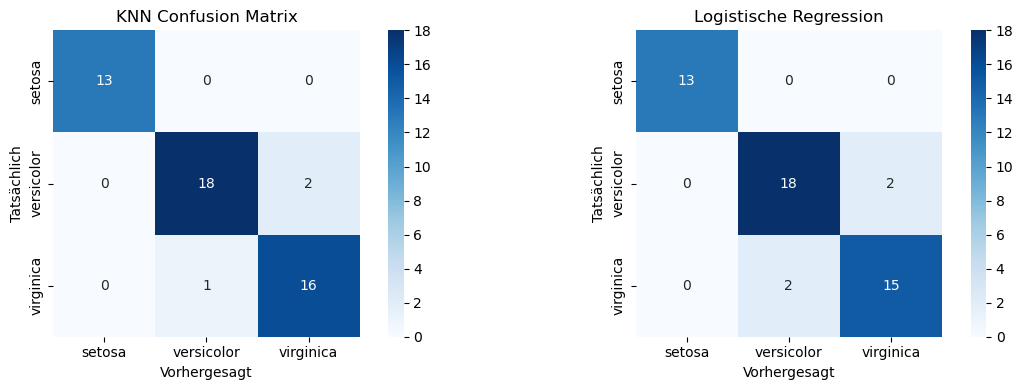

Diagonale = richtig klassifiziert
Außerhalb = Verwechslungen zwischen Klassen


In [2]:
# Confusion Matrix für KNN
knn_pred = knn.predict(X_test)
knn_cm = confusion_matrix(y_test, knn_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm, titel, pred in zip(axes,
    [knn_cm, confusion_matrix(y_test, logit.predict(X_test))],
    ['KNN Confusion Matrix', 'Logistische Regression'],
    [knn_pred, logit.predict(X_test)]):

    sns.heatmap(cm, cmap='Blues', annot=True, square=True, fmt='d', ax=ax,
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    ax.set_xlabel('Vorhergesagt')
    ax.set_ylabel('Tatsächlich')
    ax.set_title(titel)

plt.tight_layout()
plt.show()

print("Diagonale = richtig klassifiziert")
print("Außerhalb = Verwechslungen zwischen Klassen")

## 3. Precision & Recall

### Precision — "Wenn ich Alarm schlage, stimmt es auch"
```
Precision = TP / (TP + FP)
→ Von allen als positiv vorhergesagten: wie viele waren wirklich positiv?
→ Wichtig wenn: falscher Alarm teuer ist (Spam-Filter)
```

### Recall — "Ich verpasse keinen echten Fall"
```
Recall = TP / (TP + FN)
→ Von allen echten Positiven: wie viele hat das Modell gefunden?
→ Wichtig wenn: übersehen gefährlich ist (Krebs-Diagnose, Betrug)
```

### Das Dilemma
Je höher Precision → desto niedriger Recall (und umgekehrt)  
Du musst je nach Anwendungsfall entscheiden was wichtiger ist!


In [3]:
# Für multi-class brauchen wir average parameter
knn_pred = knn.predict(X_test)
logit_pred = logit.predict(X_test)

print("=== KNN ===")
print(f"Precision: {precision_score(y_test, knn_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, knn_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, knn_pred, average='weighted'):.4f}")
print()
print("=== Logistische Regression ===")
print(f"Precision: {precision_score(y_test, logit_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, logit_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, logit_pred, average='weighted'):.4f}")
print()
print("=== Detaillierter Bericht (KNN) ===")
print(classification_report(y_test, knn_pred, target_names=iris.target_names))

=== KNN ===
Precision: 0.9412
Recall:    0.9400
F1-Score:  0.9401

=== Logistische Regression ===
Precision: 0.9200
Recall:    0.9200
F1-Score:  0.9200

=== Detaillierter Bericht (KNN) ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.95      0.90      0.92        20
   virginica       0.89      0.94      0.91        17

    accuracy                           0.94        50
   macro avg       0.95      0.95      0.95        50
weighted avg       0.94      0.94      0.94        50



## 4. F1-Score & Fbeta-Score

### F1-Score — der Kompromiss
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
→ Harmonisches Mittel aus beiden
→ Gut wenn Precision und Recall gleich wichtig sind
```

### Fbeta-Score — gewichteter Kompromiss
```
Fbeta = (1 + β²) × (Precision × Recall) / (β² × Precision + Recall)

β > 1 → Recall wichtiger (z.B. β=2 für Krebs-Diagnose)
β < 1 → Precision wichtiger (z.B. β=0.5 für Spam-Filter)
β = 1 → F1-Score (beide gleich)
```


In [4]:
from sklearn.metrics import fbeta_score

knn_pred = knn.predict(X_test)

print("F1-Score (β=1, ausgeglichen):")
print(f"  {f1_score(y_test, knn_pred, average='weighted'):.4f}")
print()
print("Fbeta (β=2, Recall wichtiger — z.B. Medizin):")
print(f"  {fbeta_score(y_test, knn_pred, beta=2, average='weighted'):.4f}")
print()
print("Fbeta (β=0.5, Precision wichtiger — z.B. Spam):")
print(f"  {fbeta_score(y_test, knn_pred, beta=0.5, average='weighted'):.4f}")

F1-Score (β=1, ausgeglichen):
  0.9401

Fbeta (β=2, Recall wichtiger — z.B. Medizin):
  0.9399

Fbeta (β=0.5, Precision wichtiger — z.B. Spam):
  0.9406


## 5. Wahrscheinlichkeits-Schwellwert (Threshold) anpassen

Die logistische Regression gibt nicht nur "Klasse 0 oder 1" aus —  
sie gibt **Wahrscheinlichkeiten** aus!

Standard: Wenn P(positiv) ≥ 0.5 → Klasse 1

**Aber:** Durch Ändern des Schwellwerts kannst du Precision und Recall gezielt steuern!

```
Schwellwert senken (z.B. 0.3):
→ Mehr als positiv klassifiziert → Recall steigt, Precision sinkt
→ Gut wenn: übersehen teuer ist (Betrug, Krebs)

Schwellwert erhöhen (z.B. 0.7):
→ Weniger als positiv klassifiziert → Precision steigt, Recall sinkt
→ Gut wenn: falscher Alarm teuer ist
```


In [5]:
# Binäres Beispiel: Betrug-Erkennung (simuliert mit Iris: nur 2 Klassen)
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.3, random_state=42)

modell = LogisticRegression(max_iter=10000)
modell.fit(X_tr, y_tr)

# Wahrscheinlichkeiten für Klasse 1
wahrsch = modell.predict_proba(X_te)[:, 1]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 45)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_thresh = (wahrsch >= thresh).astype(int)
    p = precision_score(y_te, y_pred_thresh)
    r = recall_score(y_te, y_pred_thresh)
    f = f1_score(y_te, y_pred_thresh)
    print(f"{thresh:>10.1f} | {p:>10.4f} | {r:>8.4f} | {f:>8.4f}")

 Threshold |  Precision |   Recall |       F1
---------------------------------------------
       0.3 |     0.9636 |   0.9815 |   0.9725
       0.4 |     0.9636 |   0.9815 |   0.9725
       0.5 |     0.9815 |   0.9815 |   0.9815
       0.6 |     0.9813 |   0.9722 |   0.9767
       0.7 |     0.9905 |   0.9630 |   0.9765


## 6. ROC-Kurve & AUC

**ROC** = Receiver Operating Characteristic  
**AUC** = Area Under the Curve (Fläche unter der Kurve)

### Was zeigt die ROC-Kurve?
- X-Achse: False Positive Rate (FPR) = FP / (FP + TN)
- Y-Achse: True Positive Rate (TPR) = Recall = TP / (TP + FN)

Die Kurve zeigt den **Trade-off** für alle möglichen Schwellwerte gleichzeitig.

### AUC interpretieren
```
AUC = 1.0  → perfektes Modell
AUC = 0.9  → sehr gut
AUC = 0.7  → okay
AUC = 0.5  → zufälliges Raten (wertlos!)
AUC < 0.5  → schlechter als Zufall (Klassen vertauscht?)
```


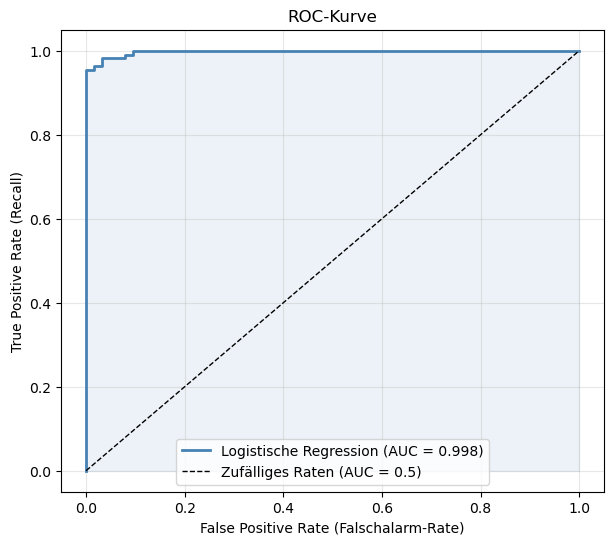

AUC-Score: 0.9976
→ Das Modell ist 100% der Zeit besser als zufälliges Raten


In [6]:
# ROC-Kurve zeichnen
wahrsch = modell.predict_proba(X_te)[:, 1]
fpr, tpr, schwellwerte = roc_curve(y_te, wahrsch)
auc = roc_auc_score(y_te, wahrsch)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistische Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Zufälliges Raten (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (Falschalarm-Rate)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-Kurve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC-Score: {auc:.4f}")
print(f"→ Das Modell ist {auc:.0%} der Zeit besser als zufälliges Raten")

## 7. Balanced Accuracy

Bei **ungleichen Klassen** ist normale Accuracy irreführend.  
**Balanced Accuracy** berechnet den Durchschnitt der Accuracy pro Klasse.

```
Balanced Accuracy = (Recall Klasse 0 + Recall Klasse 1) / 2
```

Dadurch werden alle Klassen gleich gewichtet — egal wie groß sie sind.


In [ ]:
from sklearn.metrics import balanced_accuracy_score

y_pred = modell.predict(X_te)

print(f"Normale Accuracy:   {modell.score(X_te, y_te):.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy_score(y_te, y_pred):.4f}")
print()
print("Bei ausgewogenen Klassen sind beide ähnlich.")
print("Bei unausgewogenen Klassen zeigt Balanced Accuracy das wahre Bild!")

## Zusammenfassung: Welche Metrik wann?

| Situation | Beste Metrik |
|-----------|-------------|
| Ausgewogene Klassen | Accuracy |
| Unausgewogene Klassen | Balanced Accuracy / F1 |
| Übersehen gefährlich (Krebs, Betrug) | **Recall** maximieren |
| Falscher Alarm teuer (Spam) | **Precision** maximieren |
| Beides gleich wichtig | **F1-Score** |
| Beides, aber Recall wichtiger | **Fbeta (β>1)** |
| Modell-Vergleich unabhängig vom Threshold | **AUC-ROC** |
